# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head()

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [25]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


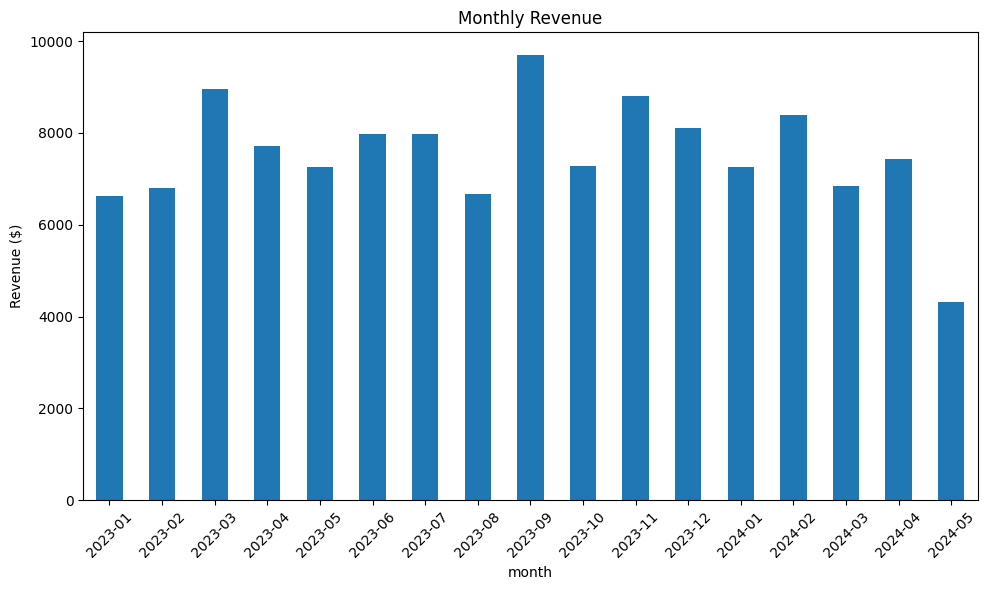

In [26]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

 Total Revenue in Last Quarter (Q4 2023) by Month:
order_date
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
Freq: M, Name: revenue, dtype: float64

 Total Revenue in Q4 2023: $ 24202.56


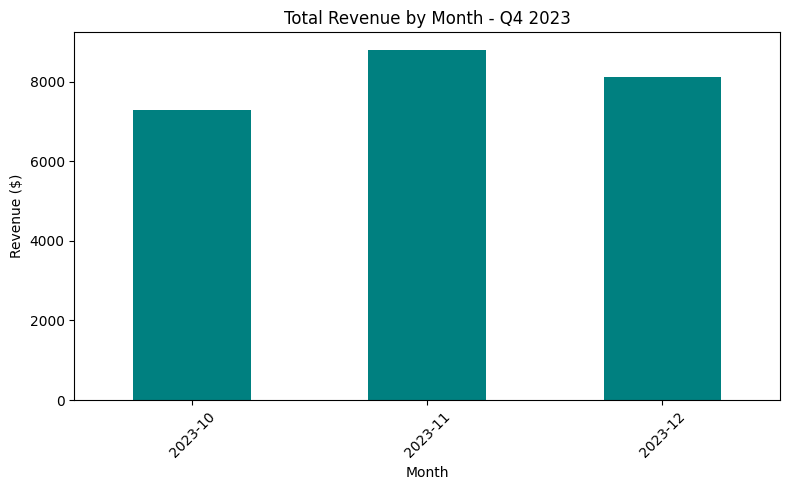

In [27]:
# Your code here

# Extract the quarter and year for filtering
data["year"] = data["order_date"].dt.year
data["quarter"] = data["order_date"].dt.quarter

# Filter for the last quarter of 2023 
last_quarter_data = data[(data["year"] == 2023) & (data["quarter"] == 4)]

# Group by month to calculate total revenue per month
revenue_by_month = last_quarter_data.groupby(data["order_date"].dt.to_period("M"))["revenue"].sum()

# Display results
print(" Total Revenue in Last Quarter (Q4 2023) by Month:")
print(revenue_by_month)
print("\n Total Revenue in Q4 2023: $", round(revenue_by_month.sum(), 2))

# Visualization
revenue_by_month.plot(kind="bar", color="teal", figsize=(8,5))
plt.title("Total Revenue by Month - Q4 2023")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

Top 5 Customers by Total Revenue Contribution:
customer_id
62    4448.39
24    3369.44
90    2976.78
92    2838.74
97    2835.62
Name: revenue, dtype: float64


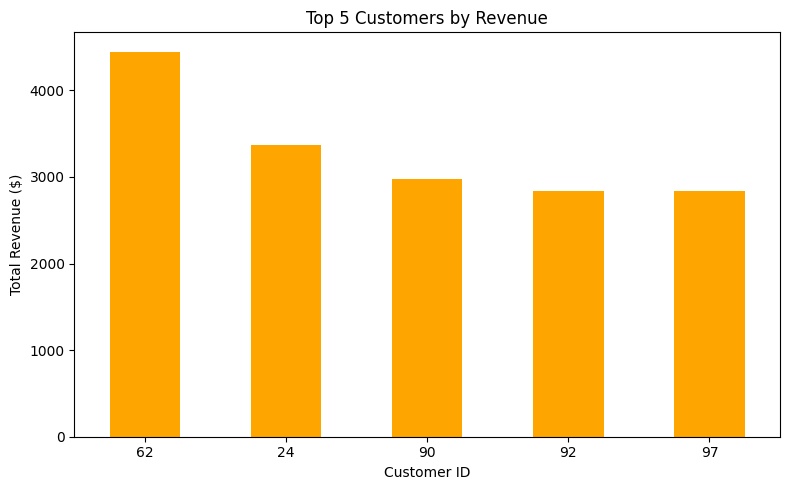

In [28]:
# Your code here

# Group by customer_id to calculate total revenue per customer
customer_revenue = data.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)

# Select top 5 customers
top_5_customers = customer_revenue.head(5)

# Display results
print("Top 5 Customers by Total Revenue Contribution:")
print(top_5_customers)

# Visualization
top_5_customers.plot(kind="bar", color="orange", figsize=(8,5))
plt.title("Top 5 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

 Average Spending per Order by Customer Segment:
customer_segment
Senior          262.133925
Professional    255.652674
Student         253.812087
Name: revenue, dtype: float64


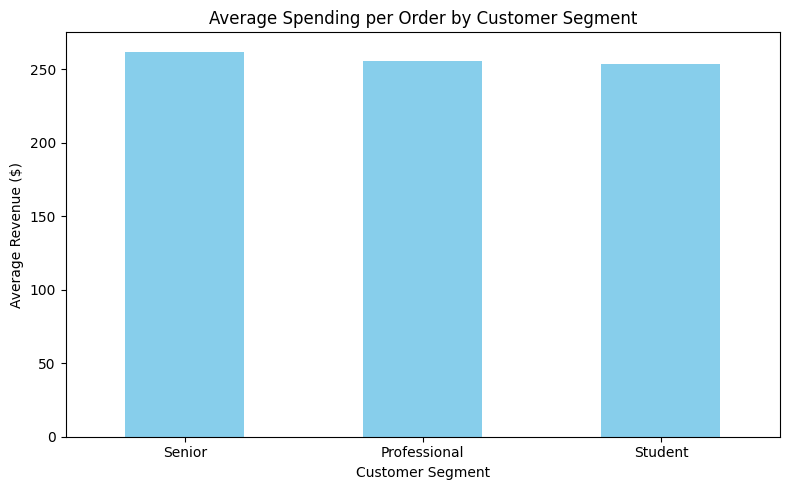

In [29]:
# Your code here

# Group by customer segment and calculate average revenue per order
segment_avg_spending = data.groupby("customer_segment")["revenue"].mean().sort_values(ascending=False)

# Display results
print(" Average Spending per Order by Customer Segment:")
print(segment_avg_spending)

# Visualization
segment_avg_spending.plot(kind="bar", color="skyblue", figsize=(8,5))
plt.title("Average Spending per Order by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

Total Revenue by Region:
region
South    34839.45
North    34351.69
East     31221.80
West     27727.73
Name: revenue, dtype: float64

Average Order Size by Region:
region
South    274.326378
North    258.283383
West     252.070273
East     240.167692
Name: revenue, dtype: float64


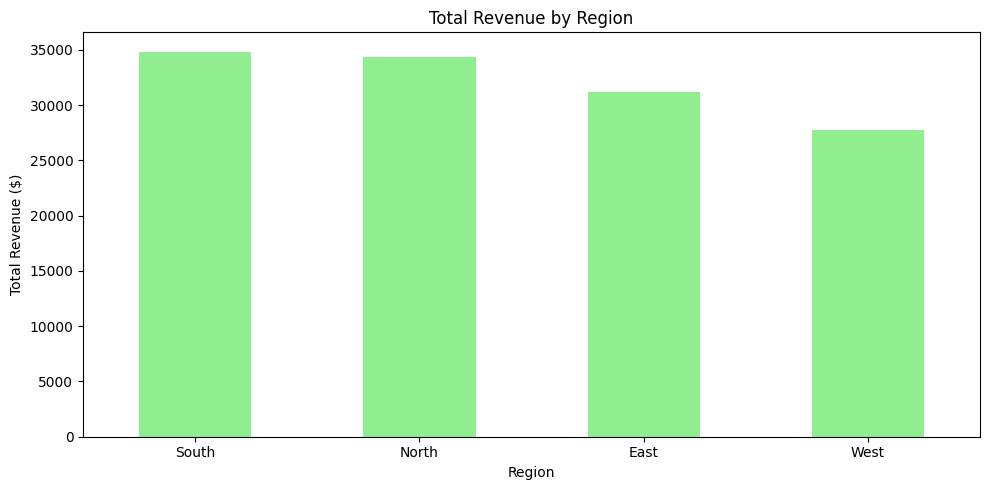

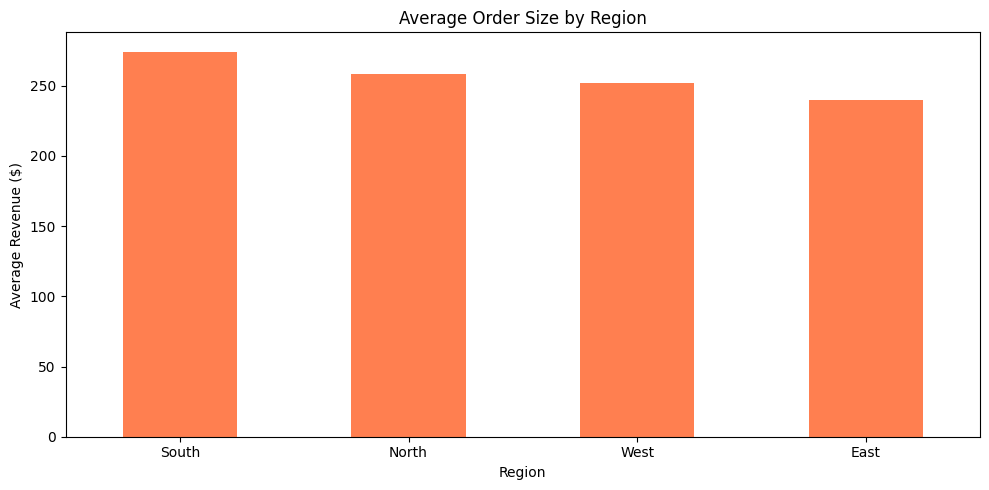

In [30]:
# Your code here

# Total revenue by region
region_revenue = data.groupby("region")["revenue"].sum().sort_values(ascending=False)

# Average order size (mean revenue per order) by region
region_avg_order = data.groupby("region")["revenue"].mean().sort_values(ascending=False)

# Display results
print("Total Revenue by Region:")
print(region_revenue)
print("\nAverage Order Size by Region:")
print(region_avg_order)

# Visualization - total revenue
plt.figure(figsize=(10,5))
region_revenue.plot(kind="bar", color="lightgreen")
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualization - average order size
plt.figure(figsize=(10,5))
region_avg_order.plot(kind="bar", color="coral")
plt.title("Average Order Size by Region")
plt.xlabel("Region")
plt.ylabel("Average Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

Total Quantity Sold by Product Category:
product_category
Home           269
Clothing       253
Sports         246
Electronics    239
Books          227
Name: quantity, dtype: int64

Total Revenue by Product Category:
product_category
Home           29871.47
Electronics    25498.31
Clothing       24804.57
Books          24046.06
Sports         23920.26
Name: revenue, dtype: float64


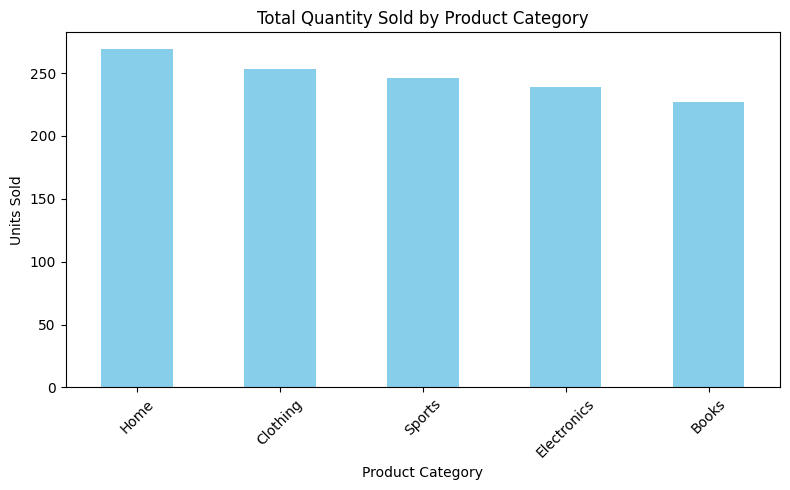

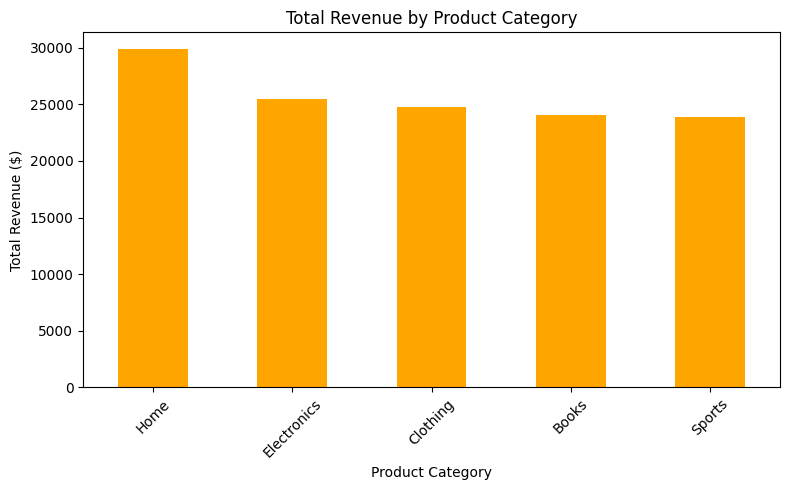

In [31]:
# Your code here
# Total quantity sold per product category
category_quantity = data.groupby("product_category")["quantity"].sum().sort_values(ascending=False)

# Total revenue per product category
category_revenue = data.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

# Display results
print("Total Quantity Sold by Product Category:")
print(category_quantity)
print("\nTotal Revenue by Product Category:")
print(category_revenue)

# Visualization - quantity
plt.figure(figsize=(8,5))
category_quantity.plot(kind="bar", color="skyblue")
plt.title("Total Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization - revenue
plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar", color="orange")
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

💲 Average Revenue per Order:
discounted
Discounted     263.831362
No Discount    248.296337
Name: revenue, dtype: float64


/tmp/ipykernel_40478/2546165613.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_revenue_comparison.index, y=avg_revenue_comparison.values, palette="Set2")


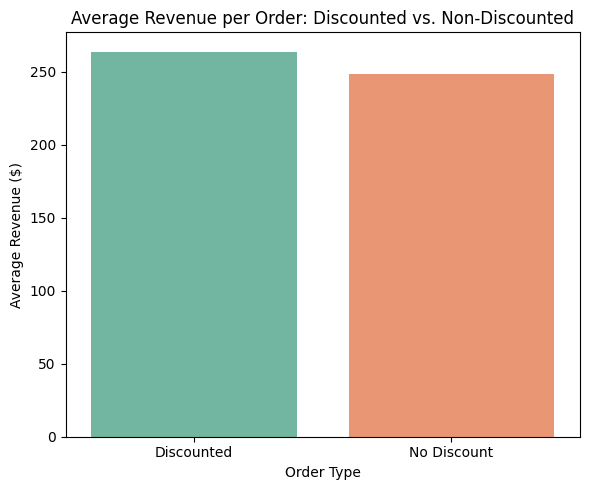

In [32]:
# Your code here

# Create a column to indicate if a discount was applied
data["discounted"] = np.where(data["discount_applied"] > 0, "Discounted", "No Discount")

# Calculate average revenue per order for each group
avg_revenue_comparison = data.groupby("discounted")["revenue"].mean()

# Display results
print("💲 Average Revenue per Order:")
print(avg_revenue_comparison)

# Visualization
plt.figure(figsize=(6,5))
sns.barplot(x=avg_revenue_comparison.index, y=avg_revenue_comparison.values, palette="Set2")
plt.title("Average Revenue per Order: Discounted vs. Non-Discounted")
plt.xlabel("Order Type")
plt.ylabel("Average Revenue ($)")
plt.tight_layout()
plt.show()


### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

Percentage of Orders by Payment Method:
payment_method
Credit Card    27.4
Gift Card      24.8
Debit Card     24.6
PayPal         23.2
Name: proportion, dtype: float64

Average Revenue per Order by Payment Method:
payment_method
Debit Card     275.98
Credit Card    257.44
Gift Card      254.36
PayPal         236.07
Name: revenue, dtype: float64


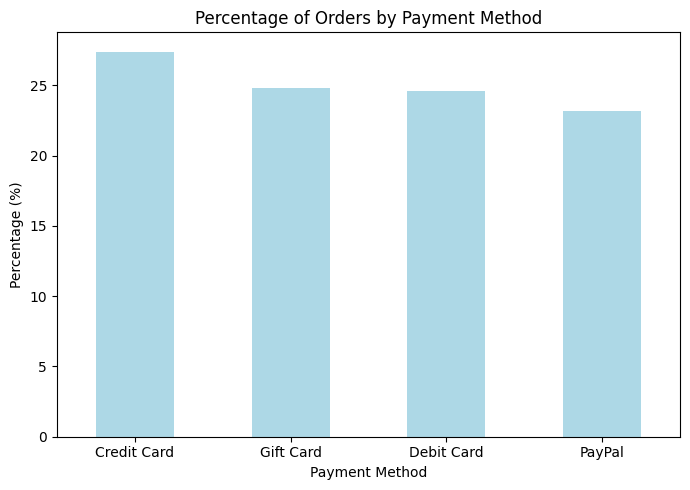

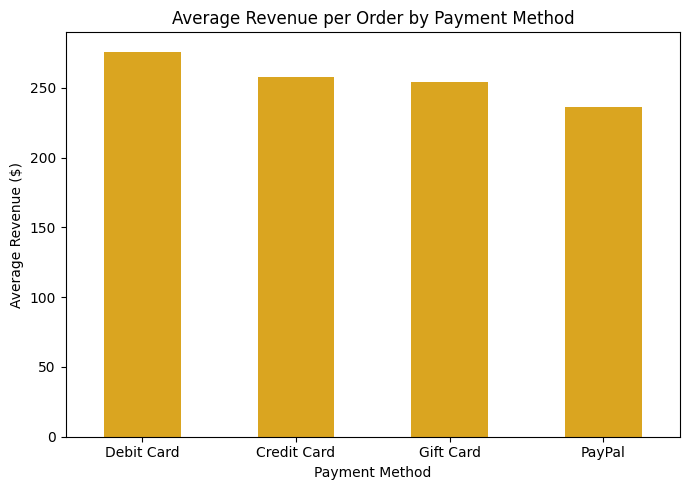

In [33]:
# Your code here
# Percentage of orders by payment method
payment_percent = data["payment_method"].value_counts(normalize=True) * 100

# Average revenue per order by payment method
payment_avg_revenue = data.groupby("payment_method")["revenue"].mean().sort_values(ascending=False)

# Display results
print("Percentage of Orders by Payment Method:")
print(payment_percent.round(2))

print("\nAverage Revenue per Order by Payment Method:")
print(payment_avg_revenue.round(2))

# Visualization - percentage of usage
plt.figure(figsize=(7,5))
payment_percent.plot(kind="bar", color="lightblue")
plt.title("Percentage of Orders by Payment Method")
plt.ylabel("Percentage (%)")
plt.xlabel("Payment Method")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualization - average revenue
plt.figure(figsize=(7,5))
payment_avg_revenue.plot(kind="bar", color="goldenrod")
plt.title("Average Revenue per Order by Payment Method")
plt.ylabel("Average Revenue ($)")
plt.xlabel("Payment Method")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

Total Revenue by Day of the Week:
day_of_week
Monday       17704.70
Tuesday      18968.41
Wednesday    18908.21
Thursday     17846.36
Friday       18522.40
Saturday     18660.35
Sunday       17530.24
Name: revenue, dtype: float64


/tmp/ipykernel_40478/2544334767.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, palette="coolwarm")


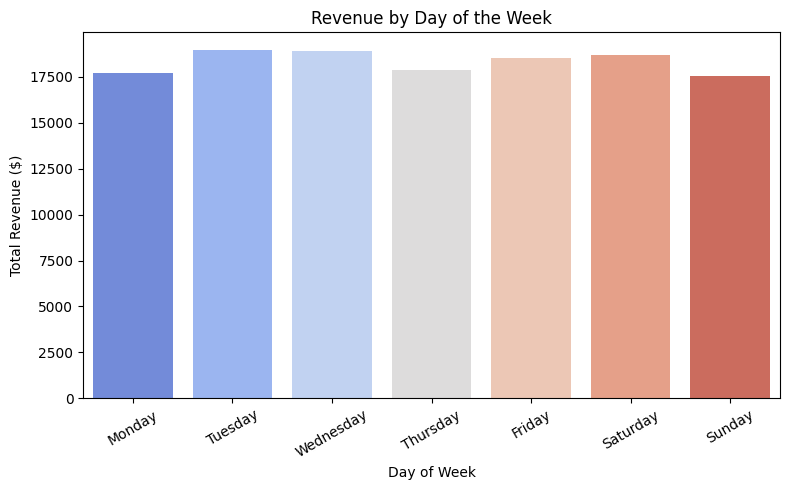

In [34]:
# Your code here

# Group by day of week and calculate total revenue
revenue_by_day = data.groupby("day_of_week")["revenue"].sum()

# Reorder days to follow the weekly sequence
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
revenue_by_day = revenue_by_day.reindex(day_order)

# Display results
print("Total Revenue by Day of the Week:")
print(revenue_by_day.round(2))

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, palette="coolwarm")
plt.title("Revenue by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

Total Estimated Profit (20% margin): $ 25628.13

Total Profit by Region:
region
South    6967.89
North    6870.34
East     6244.36
West     5545.55
Name: profit, dtype: float64


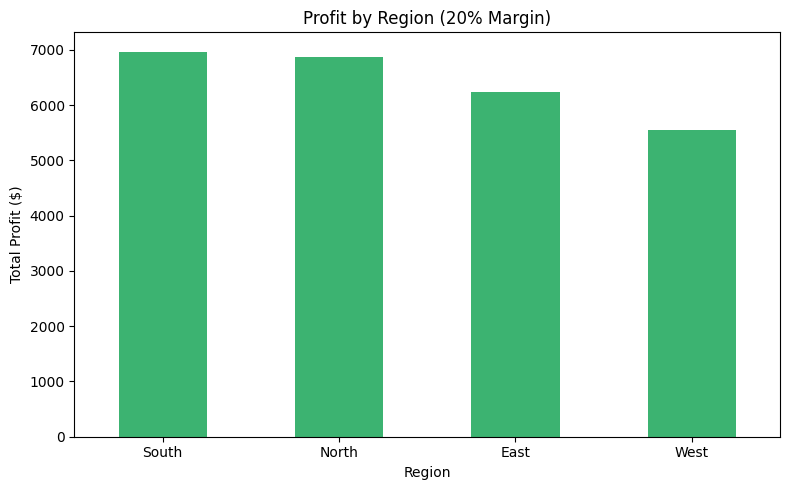

In [35]:
# Your code here
# Define profit margin and calculate profit for each order
profit_margin = 0.20
data["profit"] = data["revenue"] * profit_margin

# Total profit across all orders
total_profit = data["profit"].sum()

# Profit by region
profit_by_region = data.groupby("region")["profit"].sum().sort_values(ascending=False)

# Display results
print("Total Estimated Profit (20% margin): $", round(total_profit, 2))
print("\nTotal Profit by Region:")
print(profit_by_region.round(2))

# Visualization
plt.figure(figsize=(8,5))
profit_by_region.plot(kind="bar", color="mediumseagreen")
plt.title("Profit by Region (20% Margin)")
plt.xlabel("Region")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

Write your analysis and recommendation based on the insights you discovered from the data.

After looking at the data, here are the main findings:

-Seniors spend the most money per order.
-Homes bring in the highest revenue, and Homes sell the most units.
-The South region earns the most total revenue and profit.
-Credit Card users spend more per order.
-Weekends (Saturday and Sunday) have a fewer sales than weekdays.
-Discounted orders bring in more revenue per order.


Recommendation

The company should focus on Senior customers in the South region, especially on weekdays.
Run targeted promotions for Home products and offer credit card reward deals and discounts.
This approach can help keep profits strong while encouraging repeat purchases from high-value customers.

---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.